# **Описание**

Набор данных содержит информацию о транзакциях супермаркета. Включает в себя атрибуты заказов (даты, скидки), товарную иерархию (категории, подкатегории), географию (регионы) и портрет клиентов (сегменты).

## **Цель**
С помощью SQL-запросов извлечь из базы ключевую бизнес-информацию: определить самые маржинальные и убыточные товары, оценить влияние скидок на прибыль, а также выявить сильные и слабые регионы. На основе полученных выборок сформулировать рекомендации по оптимизации ассортимента и маркетинговой стратегии.

## **Метаданные**

Row ID => Уникальный идентификатор для каждой строки.

Order ID => Уникальный идентификатор заказа для каждого клиента.

Order Date => Дата заказа товара.

Ship Date => Дата отгрузки товара.

Ship Mode => Способ доставки, указанный клиентом.

Customer ID => Уникальный идентификатор для каждого клиента.

Customer Name => Имя клиента.

Segment => Сегмент, к которому принадлежит клиент.

Country => Страна проживания клиента.

City => Город проживания клиента.

State => Штат/регион проживания клиента.

Postal Code => Почтовый индекс клиента.

Region => Регион, к которому принадлежит клиент.

Product ID => Уникальный идентификатор товара.

Category => Категория заказанного товара.

Sub-Category => Подкатегория заказанного товара.

Product Name => Название товара.

Sales => Продажи товара.

Quantity => Количество товара.

Discount => Предоставленная скидка.

Profit => Полученная прибыль/убыток.

## **План работы**

1. Загрузка и обработка данных (очистка от пропусков и дублей).

2. Создание базы данных SQLite и импорт данных в таблицы.

3. Аналитические SQL-запросы и визуализация:

    3.1. Общая статистика

      - Общая статистика

      - Месячная динамика

      - Клиенты с наибольшим кол-вом заказов

    3.2. Продуктовый анализ

      - Продажи по категориям

      - Топ 10 прибыльных товаров

      - Топ 10 убыточных товаров

      - Категория с самой высокой средней прибылью на один заказ

      - Топ-3 подкатегории (sub_category) по объему продаж

      - Товары, которые продавались только с убытком (все заказы по ним с profit < 0)

      - Топ-3 самых продаваемых товаров в каждой категории

    3.3. Региональный и клиентский анализ

      - Продажи по регионам

      - Топ 5 городов по продажам

      - Анализ по сегментам клиентов

      - Средняя прибыль на заказ для каждого региона

      - Какой сегмент клиентов приносит наибольшую прибыль на одного клиента

    3.4. Факторный анализ

      - Влияние скидок

      - Какой способ доставки (ship_mode) приносит больше всего прибыли

      - Какой процент заказов приносит убыток (profit < 0)

      - Клиент, который потратил больше всего денег

      - Месяц с самыми высокими продажами

4. Закрытие соединения.
5. Бизнес-рекомендации.

# **Загрузка и обработка данных**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/файлы для проектов питон/sql_in_python_dead/Sample - Superstore.csv',
#                 encoding='windows-1251', index_col=False)

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1251')
pd.options.display.max_columns = None

In [10]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-','_')

In [11]:
df['order_date'] = pd.to_datetime(df['order_date']).dt.strftime('%Y-%m-%d')
df['ship_date'] = pd.to_datetime(df['ship_date']).dt.strftime('%Y-%m-%d')

In [12]:
df['sales'] = df['sales'].round(2)
df['profit'] = df['profit'].round(2)

In [13]:
df.head(2)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.58


In [14]:
# проверка на дубликаты и пропуски
print(f'Дубликаты: {df.duplicated().sum()}')
print(f'Пропуски: {df.isnull().sum().sum()}')

Дубликаты: 0
Пропуски: 0


# **Создание БД**

In [15]:
# импорт sql-библиотеки (sqlite)
import sqlite3

In [16]:
# Подключение к БД
conn = sqlite3.connect('superstore.db')

In [17]:
# Загрузка данных в SQL
df.to_sql('orders', conn, if_exists='replace', index=False)

9994

In [18]:
# Создание индексов только для колонок, которые используются в запросах (для ускорения работы )
conn.execute("CREATE INDEX IF NOT EXISTS idx_category ON orders(category)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_sub_category ON orders(sub_category)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_region ON orders(region)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_order_date ON orders(order_date)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_customer_id ON orders(customer_id)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_product_id ON orders(product_id)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_segment ON orders(segment)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_ship_mode ON orders(ship_mode)")

print(f"✅ Создано {8} индексов для наиболее часто используемых колонок")

✅ Создано 8 индексов для наиболее часто используемых колонок


In [19]:
# проверка эффективности индексов
query = """
EXPLAIN QUERY PLAN
SELECT category, SUM(profit)
FROM orders
WHERE region = 'West'
GROUP BY category
"""
explain = pd.read_sql_query(query, conn)
print(explain)

   id  parent  notused                                           detail
0   7       0        0  SEARCH orders USING INDEX idx_region (region=?)
1  12       0        0                     USE TEMP B-TREE FOR GROUP BY


In [20]:
# проверка работы запросов
query = "SELECT row_id, order_date, country, quantity, profit FROM orders LIMIT 5"
result = pd.read_sql_query(query, conn)
print(result)

   row_id  order_date        country  quantity  profit
0       1  2016-11-08  United States         2   41.91
1       2  2016-11-08  United States         3  219.58
2       3  2016-06-12  United States         2    6.87
3       4  2015-10-11  United States         5 -383.03
4       5  2015-10-11  United States         2    2.52


# **SQL-запросы и визуализация**

## **Общая статистика**

### Общие данные

In [21]:
query = """
SELECT
    COUNT(*) as total_orders,
    ROUND(SUM(sales), 2) as total_sales,
    ROUND(AVG(sales), 2) as avg_sales,
    ROUND(SUM(profit), 2) as total_profit,
    ROUND(AVG(profit), 2) as avg_profit
FROM orders
"""
result = pd.read_sql_query(query, conn)
print(result)

   total_orders  total_sales  avg_sales  total_profit  avg_profit
0          9994   2297200.65     229.86     286396.54       28.66


### Месячная динамика

      month  orders  total_sales  total_profit
0   2014-01      79     14236.90       2450.17
1   2014-02      46      4519.92        862.30
2   2014-03     157     55691.02        498.70
3   2014-04     135     28295.35       3488.83
4   2014-05     122     23648.27       2738.72
5   2014-06     135     34595.12       4976.55
6   2014-07     143     33946.37       -841.47
7   2014-08     153     27909.47       5318.07
8   2014-09     268     81777.32       8328.07
9   2014-10     159     31453.37       3448.21
10  2014-11     318     78628.73       9292.13
11  2014-12     278     69545.63       8983.58
12  2015-01      58     18174.08      -3280.97
13  2015-02      64     11951.40       2813.84
14  2015-03     138     38726.26       9732.06
15  2015-04     160     34195.25       4187.53
16  2015-05     146     30131.72       4667.83
17  2015-06     138     24797.30       3335.54
18  2015-07     140     28765.30       3288.67
19  2015-08     159     36898.31       5355.82
20  2015-09  

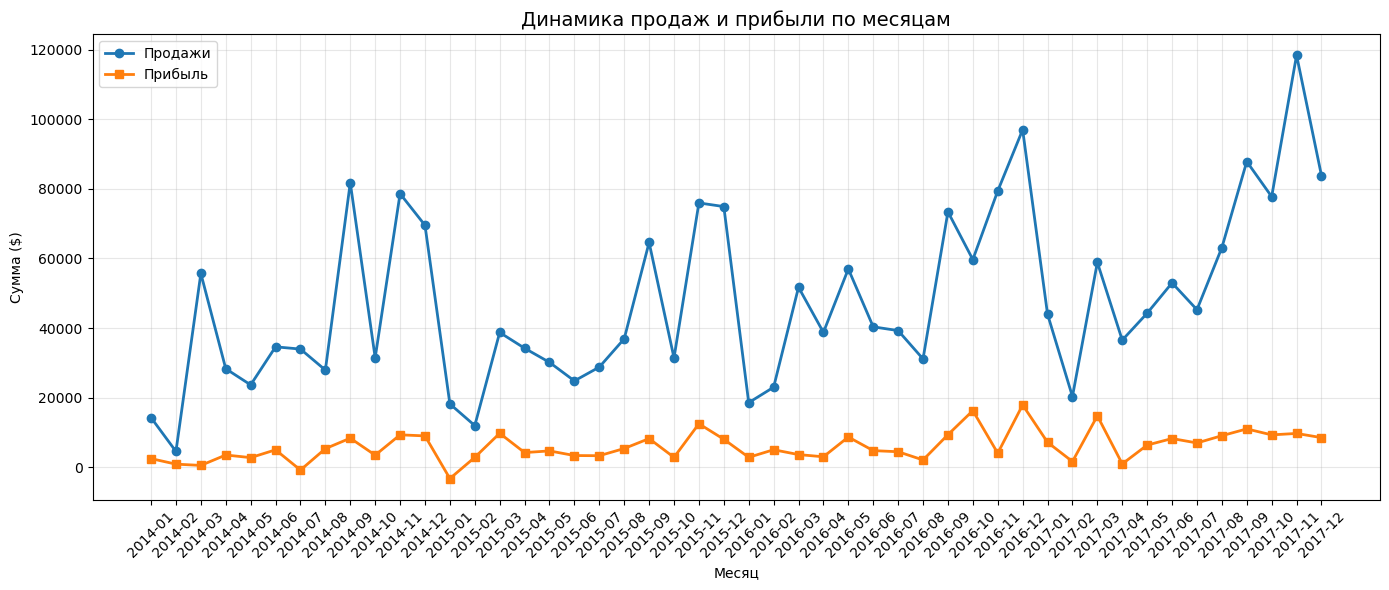

In [22]:
query = """
SELECT
    strftime('%Y-%m', order_date) as month,
    COUNT(*) as orders,
    ROUND(SUM(sales), 2) as total_sales,
    ROUND(SUM(profit), 2) as total_profit
FROM orders
GROUP BY month
ORDER BY month
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(14, 6))
plt.plot(result['month'], result['total_sales'], marker='o', linewidth=2, label='Продажи')
plt.plot(result['month'], result['total_profit'], marker='s', linewidth=2, label='Прибыль')
plt.xticks(rotation=45)
plt.title('Динамика продаж и прибыли по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Сумма ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Клиенты с наибольшим количеством заказов

         customer_name  orders  total_spent
0        William Brown      37      6160.10
1           Paul Prost      34      7252.61
2         Matt Abelman      34      4299.16
3             John Lee      34      9799.93
4          Seth Vernon      32     11470.94
5     Jonathan Doherty      32      7610.87
6         Edward Hooks      32     10310.87
7  Chloris Kastensmidt      32      3154.82
8     Zuschuss Carroll      31      8025.70
9           Emily Phan      31      5478.06


AttributeError: 'Rectangle' object has no property 'legend'

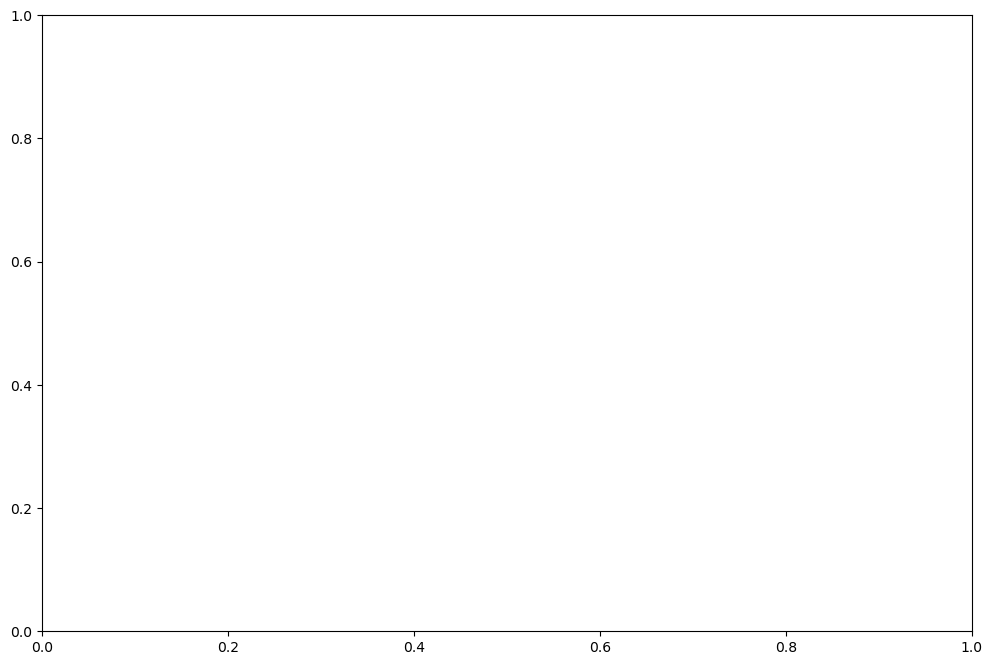

In [23]:
query = """
SELECT
    customer_name,
    COUNT(*) as orders,
    ROUND(SUM(sales), 2) as total_spent
FROM orders
GROUP BY customer_name
ORDER BY orders DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(data=result, y='customer_name', x='orders',
            hue='customer_name', palette='viridis', legend=False)
plt.title('Топ-10 клиентов по количеству заказов', fontsize=14)
plt.xlabel('Количество заказов')
plt.ylabel('Клиент')
plt.tight_layout()
plt.show()

## **Продуктовый анализ**

### Продажи по категориям

In [ ]:
query = """
SELECT
    category,
    COUNT(*) as order_count,
    ROUND(SUM(sales), 2) as total_sales,
    ROUND(SUM(profit), 2) as total_profit
FROM orders
GROUP BY category
ORDER BY total_sales DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='category', y='total_sales')
plt.title('Продажи по категориям', fontsize=14)
plt.xlabel('Категория')
plt.ylabel('Сумма продаж ($)')
plt.show()

### Топ-10 прибыльных товаров

In [ ]:
query = """
SELECT
    product_name,
    category,
    ROUND(SUM(sales), 2) as total_sales,
    ROUND(SUM(profit), 2) as total_profit
FROM orders
GROUP BY product_name
ORDER BY total_profit DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визаулизация
plt.figure(figsize=(12, 8))
sns.barplot(data=result, y='product_name', x='total_profit')
plt.title('Топ-10 самых прибыльных товаров', fontsize=14)
plt.xlabel('Прибыль ($)')
plt.ylabel('Товар')
plt.tight_layout()
plt.show()

### Топ-10 убыточных товаров

In [ ]:
query = """
SELECT
    product_name,
    category,
    ROUND(SUM(sales), 2) as total_sales,
    ROUND(SUM(profit), 2) as total_profit
FROM orders
GROUP BY product_name
ORDER BY total_profit ASC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(data=result, y='product_name', x='total_profit')
plt.title('Топ-10 самых убыточных товаров', fontsize=14)
plt.xlabel('Убыток ($)')
plt.ylabel('Товар')
plt.tight_layout()
plt.show()

### Категория с самой высокой средней прибылью на один заказ


In [ ]:
query = """
SELECT
    category,
    ROUND(SUM(sales), 2) as total_sales,
    ROUND(AVG(profit), 2) as avg_profit
FROM orders
GROUP BY category
ORDER BY avg_profit DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='category', y='avg_profit')
plt.title('Средняя прибыль на заказ по категориям', fontsize=14)
plt.xlabel('Категория')
plt.ylabel('Средняя прибыль ($)')
plt.show()

### Топ-3 подкатегории (sub_category) по объему продаж

In [ ]:
query = """
SELECT
    sub_category,
    ROUND(SUM(sales), 2) as total_sales,
    ROUND(SUM(profit), 2) as total_profit
FROM orders
GROUP BY 1
ORDER BY 2 DESC
LIMIT 3
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='sub_category', y='total_sales')
plt.title('Топ-3 подкатегории по объему продаж', fontsize=14)
plt.xlabel('Подкатегория')
plt.ylabel('Сумма продаж ($)')
plt.show()

### Товары, которые продавались только с убытком (все заказы по ним с profit < 0)

In [ ]:
query = """
SELECT
    product_name,
    ROUND(SUM(sales), 2) as total_sales,
    ROUND(SUM(profit), 2) as total_profit
FROM orders
GROUP BY product_name
HAVING SUM(profit) < 0
ORDER BY 3 ASC
"""
result = pd.read_sql_query(query, conn)
print(result)

print(f"Количество товаров, которые продаются только в убыток: {len(result)}")
print(f"Общий убыток от этих товаров: ${result['total_profit'].sum():.2f}")

### Топ-3 самых продаваемых товаров в каждой категории

In [ ]:
query = """
SELECT
  category,
  product_name,
  order_count,
  total_sales
FROM
(SELECT
    category,
    product_name,
    COUNT(*) as order_count,
    ROUND(SUM(sales), 2) as total_sales,
    RANK() OVER(PARTITION BY category ORDER BY COUNT(*) DESC) as rank
FROM orders
GROUP BY 1, 2) as t
WHERE rank <= 3
ORDER BY category, rank
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='category', y='order_count',
            hue='product_name', width=0.8)  # уменьшаем ширину столбцов
plt.title('Топ-3 самых продаваемых товаров в каждой категории', fontsize=14)
plt.xlabel('Категория')
plt.ylabel('Количество заказов')
plt.legend(title='Товар', loc='upper right', fontsize=8, frameon=True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Региональный и клиентский анализ**

### Продажи по регионам

In [ ]:
query = """
SELECT
    region,
    COUNT(*) as orders,
    ROUND(SUM(sales), 2) as total_sales,
    ROUND(SUM(profit), 2) as total_profit
FROM orders
GROUP BY region
ORDER BY total_sales DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='region', y='total_sales')
plt.title('Продажи по регионам', fontsize=14)
plt.xlabel('Регион')
plt.ylabel('Сумма продаж ($)')
plt.show()

### Топ-5 городов по продажам

In [ ]:
query = """
SELECT
    city,
    COUNT(*) as orders,
    ROUND(SUM(sales), 2) as total_sales
FROM orders
GROUP BY city
ORDER BY total_sales DESC
LIMIT 5
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=result, y='city', x='total_sales')
plt.title('Топ-5 городов по объему продаж', fontsize=14)
plt.xlabel('Сумма продаж ($)')
plt.ylabel('Город')
plt.tight_layout()
plt.show()

### Анализ по сегментам клиентов

In [ ]:
query = """
SELECT
    segment,
    COUNT(DISTINCT customer_id) as customers,
    COUNT(*) as orders,
    ROUND(SUM(sales), 2) as total_sales,
    ROUND(SUM(profit), 2) as total_profit
FROM orders
GROUP BY segment
ORDER BY total_sales DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='segment', y='total_sales')
plt.title('Продажи по сегментам клиентов', fontsize=14)
plt.xlabel('Сегмент')
plt.ylabel('Сумма продаж ($)')
plt.show()

### Средняя прибыль на заказ для каждого региона

In [ ]:
query = """
SELECT
    region,
    COUNT(*) as total_orders,
    ROUND(AVG(profit), 2) as avg_profit_per_order,
    ROUND(SUM(profit), 2) as total_profit
FROM orders
GROUP BY region
ORDER BY avg_profit_per_order DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='region', y='avg_profit_per_order')
plt.title('Средняя прибыль на заказ по регионам', fontsize=14)
plt.xlabel('Регион')
plt.ylabel('Средняя прибыль ($)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.show()

### Какой сегмент клиентов приносит наибольшую прибыль на одного клиента

In [ ]:
query = """
SELECT
    segment,
    COUNT(DISTINCT customer_id) as customer_count,
    ROUND(SUM(profit), 2) as total_profit,
    ROUND(SUM(profit) / COUNT(DISTINCT customer_id), 2) as profit_per_customer
FROM orders
GROUP BY segment
ORDER BY profit_per_customer DESC
LIMIT 1
"""
result = pd.read_sql_query(query, conn)
print(result)

print(f"Лучший сегмент: {result['segment'][0]}")
print(f"Кол-во клиентов: {result['customer_count'][0]}")
print(f"Прибыль на клиента: ${result['profit_per_customer'][0]:.2f}")

## **Факторный анализ**

### Влияние скидок

In [ ]:
query = """
SELECT
    CASE
        WHEN discount = 0 THEN '0%'
        WHEN discount > 0 AND discount <= 0.1 THEN '1-10%'
        WHEN discount > 0.1 AND discount <= 0.2 THEN '11-20%'
        WHEN discount > 0.2 AND discount <= 0.3 THEN '21-30%'
        WHEN discount > 0.3 AND discount <= 0.5 THEN '31-50%'
        ELSE '50%+'
    END as discount_range,
    COUNT(*) as orders,
    ROUND(AVG(sales), 2) as avg_sales,
    ROUND(AVG(profit), 2) as avg_profit
FROM orders
GROUP BY discount_range
ORDER BY discount_range
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=result, x='discount_range', y='avg_sales', ax=axes[0])
axes[0].set_title('Средние продажи по диапазонам скидок', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=result, x='discount_range', y='avg_profit', ax=axes[1])
axes[1].set_title('Средняя прибыль по диапазонам скидок', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Какой способ доставки (ship_mode) приносит больше всего прибыли

In [ ]:
query = """
SELECT
    ship_mode,
    COUNT(*) as total_orders,
    ROUND(SUM(profit), 2) as total_profit,
    ROUND(AVG(profit), 2) as avg_profit_per_order
FROM orders
GROUP BY ship_mode
ORDER BY total_profit DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='ship_mode', y='total_profit')
plt.title('Прибыль по способам доставки', fontsize=14)
plt.xlabel('Способ доставки')
plt.ylabel('Общая прибыль ($)')
plt.xticks(rotation=45)
plt.show()

### Какой процент заказов приносит убыток (profit < 0)

In [ ]:
query = """
SELECT
    ROUND(100.0 * SUM(CASE WHEN profit < 0 THEN 1 ELSE 0 END) / COUNT(*), 2) as loss_percent
FROM orders
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
labels = ['Прибыльные', 'Убыточные']
sizes = [100 - result['loss_percent'][0], result['loss_percent'][0]]
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.05)

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=explode, startangle=90)
plt.title(f'Доля убыточных заказов ({result["loss_percent"][0]}%)', fontsize=14)
plt.show()

### Клиент, который потратил больше всего денег

In [ ]:
query = """
SELECT
    customer_name,
    segment,
    region,
    COUNT(*) as order_count,
    ROUND(SUM(sales), 2) as total_spent,
    ROUND(SUM(profit), 2) as total_profit
FROM orders
GROUP BY customer_name
ORDER BY total_spent DESC
LIMIT 1
"""
result = pd.read_sql_query(query, conn)
print(result)

print(f"Клиент: {result['customer_name'][0]}")
print(f"Потратил: ${result['total_spent'][0]:,.2f}")
print(f"Прибыль от клиента: ${result['total_profit'][0]:,.2f}")

Клиент потратил больше всего денег, но для компании он оказался убыточным

### Прибыль и убытки по товарам клиента

In [ ]:
query = """
SELECT
    product_name,
    category,
    sub_category,
    COUNT(*) as orders,
    ROUND(SUM(sales), 2) as total_sales,
    ROUND(SUM(profit), 2) as total_profit
FROM orders
WHERE customer_name = 'Sean Miller'
GROUP BY product_name
HAVING total_profit < 1
ORDER BY total_profit ASC
"""
result = pd.read_sql_query(query, conn)
print(result)

### Месяц с самыми высокими продажами

In [ ]:
query = """
WITH monthly_profit AS (
    SELECT
        strftime('%Y', order_date) as year,
        strftime('%m', order_date) as month,
        ROUND(SUM(profit), 2) as total_profit,
        RANK() OVER (PARTITION BY strftime('%Y', order_date) ORDER BY SUM(profit) DESC) as rank
    FROM orders
    GROUP BY year, month
)
SELECT
    year,
    month,
    total_profit
FROM monthly_profit
WHERE rank = 1
ORDER BY year
"""
result = pd.read_sql_query(query, conn)
print(result)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='year', y='total_profit',
            hue='year', palette='viridis', legend=False)
plt.title('Прибыль в самом прибыльном месяце по годам', fontsize=14)
plt.xlabel('Год')
plt.ylabel('Прибыль ($)')

# Добавляем подписи над столбцами с месяцем
for i, row in result.iterrows():
    plt.text(i, row['total_profit'] + 200, f"Месяц {row['month']}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Закрытие соединения

In [ ]:
conn.close()

# **Выводы**

## Общая статистика
- **9994 заказа** на общую сумму **$2.3 млн**

- **Общая прибыль: 286.4 тыс.** (средняя прибыль на заказ: $28.66)

## Продуктовый анализ
- **Technology** — лидер по продажам ($836 тыс.) и прибыли ($145 тыс.)

- **Furniture** — самые низкие продажи ($742 тыс.), минимальная прибыль ($18.5 тыс.)

- **Самый прибыльный товар:** Canon imageCLASS 2200 Advanced Copier ($25.2 тыс.)

- **Самый убыточный товар:** Cubify CubeX 3D Printer Double Head Print ($-8.9 тыс.)

- **Топ-подкатегории:** Phones ($330 тыс.), Chairs ($328 тыс.), Storage ($224 тыс.)

- **301 товар** продается только в убыток (общий убыток: $77 тыс.)

## Региональный анализ
- **West** — лучший регион (продажи $725 тыс., прибыль $108 тыс.)

- **Central** — самый слабый регион (продажи $501 тыс., прибыль $39.7 тыс.)

- **Средняя прибыль на заказ:** West ($33.85) > East ($32.14) > South ($28.86) > Central ($17.09)

## Клиентский анализ
- **Consumer** — самый крупный сегмент (5191 заказ, $1.16 млн продаж)

- **Home Office** — самый прибыльный на клиента ($407 на клиента)

## Факторный анализ
- **18.72%** заказов убыточны

- **Скидки 30%+** приносят убыток (средняя прибыль отрицательная)

- **Standard Class** — самый популярный и прибыльный способ доставки

- **Лучший месяц по годам:** ноябрь (2014, 2015) и декабрь (2016)



# **Бизнес-рекомендации**

## 1. Оптимизация ассортимента
**Проблема:** 301 товар продается в убыток, 3D-принтеры особенно убыточны.

**Решение:** Пересмотреть ценообразование на убыточные товары или исключить их из ассортимента. Сфокусироваться на топ-прибыльных категориях (Technology).

## 2. Управление скидками
**Проблема:** Скидки выше 20% делают заказы убыточными.

**Решение:** Ограничить скидки 10-15% (максимум 20%). Для скидок 30%+ ввести обязательное согласование.

## 3. Региональная стратегия
**Проблема:** Central регион отстает по прибыли.

**Решение:** Усилить маркетинг в Central, проанализировать причины низкой маржинальности (логистика? цены? ассортимент?).

## 4. Работа с клиентами
**Проблема:** Клиент Sean Miller потратил больше всех (
25
k
)
,
нопринесубыток
(
25k),но принесут убыток(-1.9k) из-за Cisco TelePresence.

**Решение:** Для крупных клиентов внедрять персональный подход: предлагать альтернативы убыточным товарам, пересматривать ценообразование.

## 5. Улучшение доставки
**Проблема:** Same Day доставка приносит наименьшую прибыль.

**Решение:** Пересмотреть тарифы на Same Day или ограничить ее применение для убыточных товаров.

## 6. Сезонность
**Вывод:** Ноябрь-декабрь — пиковые месяцы.

**Решение:** Усилить маркетинговые кампании в этот период, увеличить товарные запасы.


